In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

print("Ready!")
print(f"Layers: {model.config.n_layer}")
print(f"Heads:  {model.config.n_head}")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2859.27it/s]


Ready!
Layers: 12
Heads:  12


In [2]:
text = "The cat sat on the"
inputs = tokenizer(text, return_tensors="pt")

# Normal output
with torch.no_grad():
    normal_output = model(**inputs)

normal_logits = normal_output.logits[0, -1, :]
normal_probs  = torch.softmax(normal_logits, dim=0)

top_word = tokenizer.decode([normal_probs.argmax().item()])
print(f"Normal top word: '{top_word}' ({normal_probs.max():.4f})")


kl_matrix = torch.zeros(12, 12)  # [layers, heads]

for layer_idx in range(12):
    for head_idx in range(12):
        
        def silence_head_hook(module, input, output):
            
            head_dim = model.config.n_embd // model.config.n_head  # 64
            start    = head_idx * head_dim
            end      = start + head_dim
            modified = output[0].clone()
            modified[:, :, start:end] = 0
            return (modified,) + output[1:]
        
        hook = model.transformer.h[layer_idx].attn.register_forward_hook(
            silence_head_hook)
        
        with torch.no_grad():
            silenced_output = model(**inputs)
        
        hook.remove()
        
        silenced_probs = torch.softmax(
            silenced_output.logits[0, -1, :], dim=0)
        
        kl = F.kl_div(
            torch.log(silenced_probs + 1e-10),
            normal_probs + 1e-10,
            reduction='sum'
        ).item()
        
        kl_matrix[layer_idx, head_idx] = kl

print("KL divergence matrix ready!")
print(f"Max KL: {kl_matrix.max():.4f} at layer {kl_matrix.max(dim=1).values.argmax()+1}, head {kl_matrix.max(dim=0).values.argmax()+1}")

Normal top word: ' floor' (0.0764)
KL divergence matrix ready!
Max KL: 0.0041 at layer 12, head 8


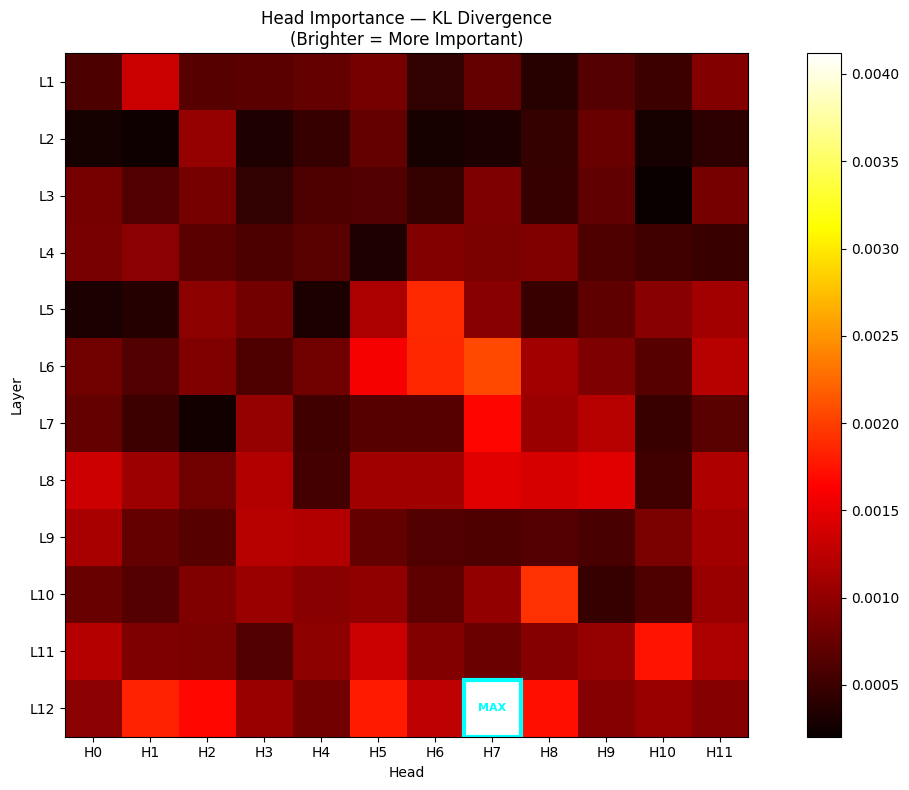


Top 5 Most Important Heads:
  Layer 12, Head  7: KL = 0.0041
  Layer  6, Head  7: KL = 0.0021
  Layer 10, Head  8: KL = 0.0019
  Layer  5, Head  6: KL = 0.0019
  Layer  6, Head  6: KL = 0.0019


In [3]:
fig, ax = plt.subplots(figsize=(12, 8))

im = ax.imshow(kl_matrix.numpy(), cmap="hot")

ax.set_xlabel("Head")
ax.set_ylabel("Layer")
ax.set_xticks(range(12))
ax.set_yticks(range(12))
ax.set_xticklabels([f"H{i}" for i in range(12)])
ax.set_yticklabels([f"L{i+1}" for i in range(12)])
ax.set_title("Head Importance — KL Divergence\n"
             "(Brighter = More Important)")


max_layer = kl_matrix.max(dim=1).values.argmax().item()
max_head  = kl_matrix.max(dim=0).values.argmax().item()
ax.add_patch(plt.Rectangle(
    (max_head-0.5, max_layer-0.5), 1, 1,
    fill=False, edgecolor="cyan", linewidth=3
))
ax.text(max_head, max_layer, "MAX", 
        ha="center", va="center", 
        color="cyan", fontsize=8, fontweight="bold")

plt.colorbar(im)
plt.tight_layout()
plt.show()


flat_kl = kl_matrix.flatten()
top5_idx = flat_kl.topk(5).indices

print("\nTop 5 Most Important Heads:")
for idx in top5_idx:
    l = idx // 12
    h = idx % 12
    print(f"  Layer {l+1:2d}, Head {h:2d}: KL = {kl_matrix[l,h]:.4f}")

* Layer 12, Head 7 is the most important for this sentence
* Head 7 is important across multiple layers
* KL values are small — no single head is critical
* Attention is distributed across many heads
